# **Assignment 2**: Formula 1 Constructor Performance, 1981–2020

Ladin Toplu

## **Summary of findings**
XXXX

### Loading libraries
First I will load pandas, numpy, and matplotlib

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading data
I will load the necessary F1 datasets. I will be using four datasets throughout the analysis. `constructor_results` contains the points earned by each constructor in each race, while `races` provides the year of each race and `constructors` provides the constructor names. I also use `results`, which contains driver-level race results, to identify the different drivers who raced for Ferrari.

In [2]:
# Read Formula 1 datasets
constructor_results = pd.read_csv("data_raw/constructor_results.csv")
races = pd.read_csv("data_raw/races.csv")
constructors = pd.read_csv("data_raw/constructors.csv")
results = pd.read_csv("data_raw/results.csv")

### Data prep and quality checks

Before merging the datasets, I will inspect the variables needed for the analysis and check their data types and missing values. The main identifiers used to connect the datasets are `raceId` and `constructorId`.

In [3]:
# Check data types
# constructor_results[["raceId", "constructorId", "points"]].dtypes
# races[["raceId", "year"]].dtypes
# constructors[["constructorId", "name"]].dtypes
# results[["raceId", "driverId", "constructorId", "points"]].dtypes

# Check missing values in key variables
# print(constructor_results[["raceId", "constructorId", "points"]].isna().sum())
# print(races[["raceId", "year"]].isna().sum())
# print(constructors[["constructorId", "name"]].isna().sum())
# print(results[["raceId", "driverId", "constructorId", "points"]].isna().sum())

The variables I need to use for the analysis have the expected data types. There are also no missing values in the variables I will use for merging and analysis, so I do not need to clean these further. I am ready to merge the datasets.

In [4]:
# Rename constructor name before merging for clarity
dict_rename_constructors = {"name": "constructor_name"}
constructors = constructors.rename(columns=dict_rename_constructors)

## **(a) Three constructors that earned the most points and average comparison, 1981–2020**

### Merge data

To calculate the total points earned by each constructor between 1981 and 2020, I merge `constructor_results` with information on the year of each race from `races` and the constructor names from `constructors`. I use `raceId` and `constructorId` to merge the datasets.

In [5]:
# Merge constructor results with race year
constructor_races = pd.merge(
    constructor_results,
    races[["raceId", "year"]],
    on="raceId",
    how="left"
)

# Merge with constructor names
constructor_data = pd.merge(
    constructor_races,
    constructors[["constructorId", "constructor_name"]],
    on="constructorId",
    how="left"
)

# Check merge
# print("Before merge:", len(constructor_results))
# print("After merge:", len(constructor_data))
# constructor_data[["year", "constructor_name"]].isna().sum()

### Calculating constructor points


In [6]:
# Restrict data to races between 1981 and 2020
constructor_1981_2020 = constructor_data.query(
    "year >= 1981 & year <= 2020"
)

# Total points by constructor
constructor_points_1981_2020 = (
    constructor_1981_2020
    .groupby("constructor_name")
    .agg(total_points=("points", "sum"))
    .sort_values("total_points", ascending=False)
)
constructor_points_1981_2020.head()

# Average total points (all constructors)
average_points_1981_2020 = constructor_points_1981_2020["total_points"].mean()
average_points_1981_2020

# Top 3 constructors by total points
top3_1981_2020 = constructor_points_1981_2020.head(3).copy()
top3_1981_2020

# Compare top 3 with the average across constructors
top3_1981_2020["average_points"] = average_points_1981_2020

top3_1981_2020["difference_from_average"] = (
    top3_1981_2020["total_points"] -
    top3_1981_2020["average_points"]
)

# Final table for the comparison of top 3 constructors with the average across all constructors
top3_table_1981_2020 = (
    top3_1981_2020
    .reset_index()
    .rename(columns={
        "constructor_name": "Constructor",
        "total_points": "Total Points",
        "average_points": "Average Across Constructors",
        "difference_from_average": "Difference from Average"
    })
)

top3_table_1981_2020.style.format({
    "Total Points": "{:,.1f}",
    "Average Across Constructors": "{:,.1f}",
    "Difference from Average": "{:,.1f}"
}).hide(axis="index").set_caption(
    "Top Three Formula 1 Constructors by Total Points, 1981–2020"
)

Constructor,Total Points,Average Across Constructors,Difference from Average
Ferrari,"7,374.0",532.2,"6,841.8"
Mercedes,"5,685.0",532.2,"5,152.8"
McLaren,"5,229.5",532.2,"4,697.3"


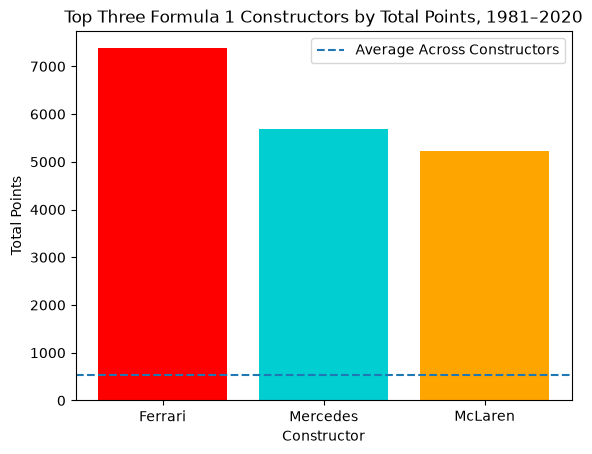

In [7]:
# Constructor colors, matching with their team color :)
constructor_colors = {
    "Ferrari": "red",
    "Mercedes": "darkturquoise",
    "McLaren": "orange",
    "Red Bull": "darkblue"
}

# Graph showing top 3 and average, 1981–2020
plt.bar(
    top3_table_1981_2020["Constructor"],
    top3_table_1981_2020["Total Points"],
    color=[constructor_colors[constructor] for constructor in top3_table_1981_2020["Constructor"]]
)

plt.axhline(
    y=average_points_1981_2020,
    linestyle="--",
    label="Average Across Constructors"
)

plt.xlabel("Constructor")
plt.ylabel("Total Points")
plt.title("Top Three Formula 1 Constructors by Total Points, 1981–2020")
plt.legend()

plt.show()

**Interpretation:** Ferrari earned the most constructor points (7,374), followed by Mercedes (5,685) and McLaren (5,229.5). These top 3 constructors were way above the average of 532.2 points across constructors. Ferrari had the largest difference from the average, earning 6,841.8 more points than the average constructor.

## **(b) Three constructors that earned the most points and average comparison, 2001-2020**

I will basically repeat the analysis for 2001 to 2020.


In [8]:
# Restrict data to races between 2001 and 2020
constructor_2001_2020 = constructor_data.query(
    "year >= 2001 & year <= 2020"
)

### Calculating constructor points

In [9]:
# Total points by constructor
constructor_points_2001_2020 = (
    constructor_2001_2020
    .groupby("constructor_name")
    .agg(total_points=("points", "sum"))
    .sort_values("total_points", ascending=False)
)

# Average total points (all constructors)
average_points_2001_2020 = constructor_points_2001_2020["total_points"].mean()

# Top 3 constructors by total points
top3_2001_2020 = constructor_points_2001_2020.head(3).copy()

# Compare top 3 with the average across constructors
top3_2001_2020["average_points"] = average_points_2001_2020

top3_2001_2020["difference_from_average"] = (
    top3_2001_2020["total_points"] -
    top3_2001_2020["average_points"]
)

# Final table for the comparison of top 3 constructors with the average across all constructors
top3_table_2001_2020 = (
    top3_2001_2020
    .reset_index()
    .rename(columns={
        "constructor_name": "Constructor",
        "total_points": "Total Points",
        "average_points": "Average Across Constructors",
        "difference_from_average": "Difference from Average"
    })
)

top3_table_2001_2020.style.format({
    "Total Points": "{:,.1f}",
    "Average Across Constructors": "{:,.1f}",
    "Difference from Average": "{:,.1f}"
}).hide(axis="index").set_caption(
    "Top Three Formula 1 Constructors by Total Points, 2001–2020"
)

Constructor,Total Points,Average Across Constructors,Difference from Average
Ferrari,"5,862.0",786.0,"5,076.0"
Mercedes,"5,685.0",786.0,"4,899.0"
Red Bull,"5,043.5",786.0,"4,257.5"


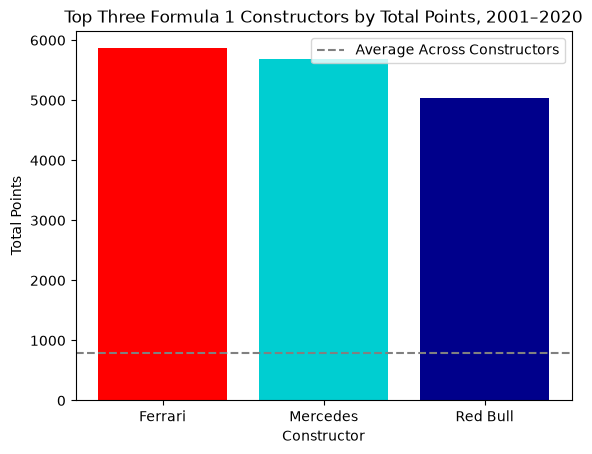

In [10]:
# Graph showing top 3 and average, 2001–2020
colors_2001_2020 = [
    constructor_colors[constructor]
    for constructor in top3_table_2001_2020["Constructor"]
]

plt.bar(
    top3_table_2001_2020["Constructor"],
    top3_table_2001_2020["Total Points"],
    color=colors_2001_2020
)

plt.axhline(
    y=average_points_2001_2020,
    color="gray",
    linestyle="--",
    label="Average Across Constructors"
)

plt.xlabel("Constructor")
plt.ylabel("Total Points")
plt.title("Top Three Formula 1 Constructors by Total Points, 2001–2020")
plt.legend()

plt.show()

**Interpretation:** Ferrari earned the most constructor points (5,862), followed by Mercedes (5,685) and Red Bull (5,043.5). These top 3 constructors were way above the average of 786 points across constructors. Ferrari had the largest difference from the average, earning 5,076 more points than the average constructor.

## **(c) Changes in rankings between the two time periods**

I will assign ranks to the top three constructors based on their total points and combine the results into a single table.

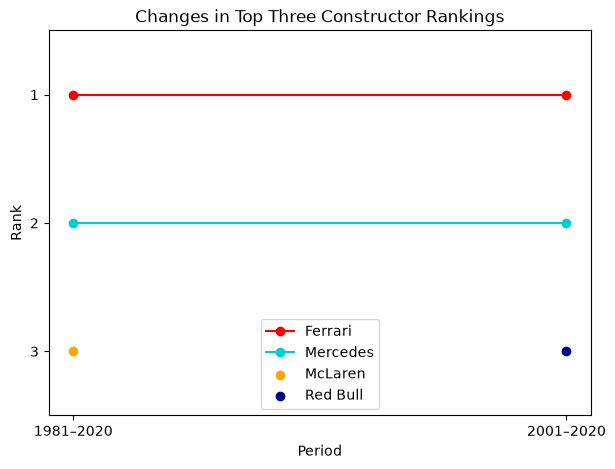

In [11]:
# Rankings for 1981–2020

ranking_1981_2020 = top3_table_1981_2020[["Constructor"]].copy()
ranking_1981_2020["Rank 1981–2020"] = [1, 2, 3]

# Rankings for 2001–2020

ranking_2001_2020 = top3_table_2001_2020[["Constructor"]].copy()
ranking_2001_2020["Rank 2001–2020"] = [1, 2, 3]

# Rankings across periods

ranking_comparison = pd.merge(
    ranking_1981_2020,
    ranking_2001_2020,
    on="Constructor",
    how="outer"
)

ranking_comparison

# Create ranking data for the two periods

rankings = pd.DataFrame({
    "Constructor": ["Ferrari", "Mercedes", "McLaren", "Red Bull"],
    "1981–2020": [1, 2, 3, np.nan],
    "2001–2020": [1, 2, np.nan, 3]
})

rankings

# Plot changes in constructor rankings

plt.figure(figsize=(7, 5))

# Constructors appearing in the top three in both periods
plt.plot(
    ["1981–2020", "2001–2020"],
    [1, 1],
    marker="o",
    color="red",
    label="Ferrari"
)

plt.plot(
    ["1981–2020", "2001–2020"],
    [2, 2],
    marker="o",
    color="darkturquoise",
    label="Mercedes"
)

# Constructors appearing in the top three in only one period
plt.scatter(
    "1981–2020", 3,
    color="orange",
    label="McLaren"
)

plt.scatter(
    "2001–2020", 3,
    color="darkblue",
    label="Red Bull"
)

plt.yticks([1, 2, 3])
plt.ylim(3.5, 0.5)

plt.xlabel("Period")
plt.ylabel("Rank")
plt.title("Changes in Top Three Constructor Rankings")
plt.legend()

plt.show()

**Interpretation:** Ferrari and Mercedes maintained their rankings across the two periods, remaining first and second. The only change among the top three was in third place: McLaren ranked third between 1981 and 2020; Red Bull ranked third between 2001 and 2020.

## **(d) Number of Ferrari drivers, 1981–2020**

I will use the driver-level `results` dataset for this part, since we need to identify the number of different drivers who raced for Ferrari between 1981 and 2020. I merge it with race years and constructor names, restrict the data to Ferrari and the relevant years, and count the number of unique `driverId` values.


In [12]:
# Merge driver results with race year
driver_races = pd.merge(
    results,
    races[["raceId", "year"]],
    on="raceId",
    how="left"
)

# Merge with constructor names
driver_data = pd.merge(
    driver_races,
    constructors[["constructorId", "constructor_name"]],
    on="constructorId",
    how="left"
)

# Checks
# print("Before merge:", len(results))
# print("After merge:", len(driver_data))
# driver_data[["year", "constructor_name"]].isna().sum()

# Restrict data to Ferrari between 1981 and 2020
ferrari_1981_2020 = driver_data.query(
    "constructor_name == 'Ferrari' & year >= 1981 & year <= 2020"
)

# Count different Ferrari drivers
ferrari_driver_count = ferrari_1981_2020["driverId"].nunique()

ferrari_driver_count

# Check
# ferrari_1981_2020["driverId"].unique()

25

**Interpretation:** Ferrari had 25 drivers between 1981 and 2001.

## **(e) Ferrari's best year between 1981–2020**

I define Ferrari's best year as the year in which they earned the most points. I restrict the data to Ferrari between 1981 and 2020 and sum its points for each year.

In [13]:
# Restrict data to Ferrari between 1981 and 2020
ferrari_constructor = constructor_data.query(
    "constructor_name == 'Ferrari' & year >= 1981 & year <= 2020"
)

# Total points by year
ferrari_year_points = (
    ferrari_constructor
    .groupby("year")
    .agg(total_points=("points", "sum"))
    .sort_values("total_points", ascending=False)
)

ferrari_year_points.head(1)

,total_points
year,
2018,571.0


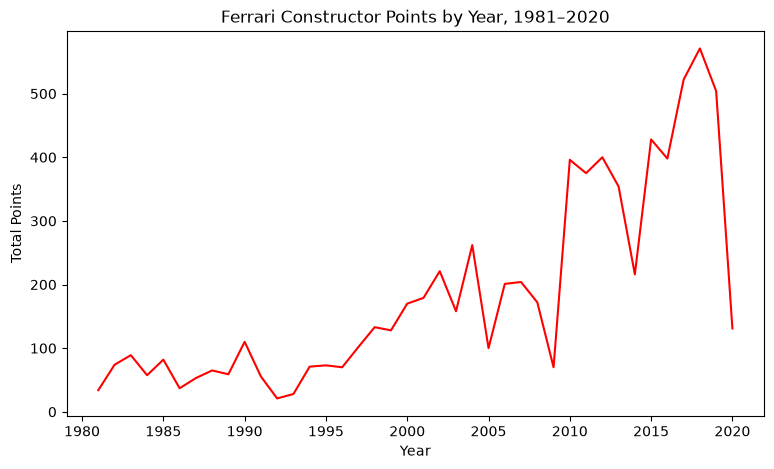

In [14]:
# Graph of points over time

ferrari_year_points.sort_index().plot(
    kind="line",
    y="total_points",
    color="red",
    figsize=(9, 5),
    legend=False
)

plt.xlabel("Year")
plt.ylabel("Total Points")
plt.title("Ferrari Constructor Points by Year, 1981–2020")

plt.show()

**Interpretation:** Ferrari's best year was 2018. They earned 517 points during that year.

## **(f) New insights: Which team won where?**

I will see the countries in which Ferrari, Mercedes, McLaren, and Red Bull won the most races between 1981 and 2020. I use the circuit data to identify the country where each race took place and compare the five countries with the most race wins for each constructor.

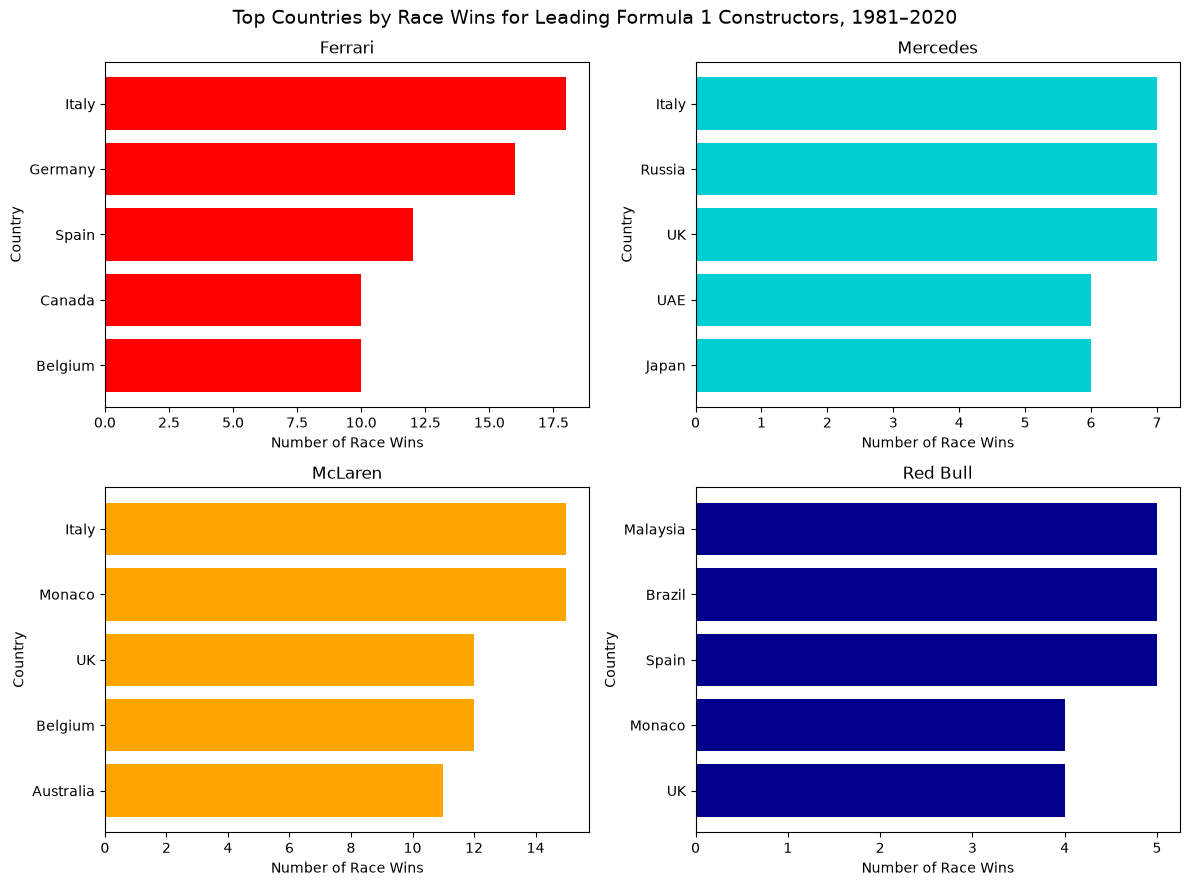

In [15]:
# Circuit data
circuits = pd.read_csv("data_raw/circuits.csv")

# Merge results with race
country_data = pd.merge(
    results,
    races[["raceId", "year", "circuitId"]],
    on="raceId",
    how="left"
)

# Merge with constructor names
country_data = pd.merge(
    country_data,
    constructors[["constructorId", "constructor_name"]],
    on="constructorId",
    how="left"
)

# Merge with circuit countries
country_data = pd.merge(
    country_data,
    circuits[["circuitId", "country"]],
    on="circuitId",
    how="left"
)

# Check number of observations before and after merging
# print("Before merge:", len(results))
# print("After merge:", len(country_data))

# Select race wins
top_team_wins = country_data.query(
    "constructor_name in ['Ferrari', 'Mercedes', 'McLaren', 'Red Bull'] & year >= 1981 & year <= 2020 & positionOrder == 1"
)

# Count race wins by constructor and country
wins_by_country = (
    top_team_wins
    .groupby(["constructor_name", "country"])
    .agg(number_wins=("raceId", "count"))
    .reset_index()
)

# Constructor colors
constructor_colors = {
    "Ferrari": "red",
    "Mercedes": "darkturquoise",
    "McLaren": "orange",
    "Red Bull": "darkblue"
}

# Create a 2 x 2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

teams = ["Ferrari", "Mercedes", "McLaren", "Red Bull"]
axes = axes.flatten()

for team, ax in zip(teams, axes):
    
    # Select the five countries with the most race wins
    team_data = (
        wins_by_country
        .query("constructor_name == @team")
        .sort_values("number_wins", ascending=False)
        .head(5)
        .sort_values("number_wins")
    )
    
    # Plot race wins by country
    ax.barh(
        team_data["country"],
        team_data["number_wins"],
        color=constructor_colors[team]
    )
    
    ax.set_title(team)
    ax.set_xlabel("Number of Race Wins")
    ax.set_ylabel("Country")

fig.suptitle(
    "Top Countries by Race Wins for Leading Formula 1 Constructors, 1981–2020",
    fontsize=14
)

plt.tight_layout()
plt.show()

## **(g) Interpretation**

Ferrari won the most races in Italy (18), followed by Germany (16), while McLaren had the most wins in Italy and Monaco (15 each). Mercedes and Red Bull had fewer wins overall during this period, with Italy, Russia, and the UK tied at 7 wins each for Mercedes and Malaysia, Brazil and Spain tying at 5 for Red Bull.

These differences show where each constructor had the most race wins between 1981 and 2020. However, countries differ in the number of Formula 1 races they hosted during this period, so the number of wins also reflects differences in the number of opportunities to win. Therefore, these results should not be interpreted as win rates or as showing where each constructor performed best.